# НИРС Прогноз оценки вин (Wine Reviews)


- Датасет: Wine Reviews (Kaggle) с информацией о цене, стране, регионе, сорте и описаниях вин.
- Ссылка: https://www.kaggle.com/datasets/zynicide/wine-reviews

## 1. Загрузка и обзор данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

df = pd.read_csv('wine_reviews.csv')
df.head()

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,variety,winery
0,0,US,This tremendous 100% varietal wine hails from ...,Martha's Vineyard,96,235.0,California,Napa Valley,Napa,Cabernet Sauvignon,Heitz
1,1,Spain,"Ripe aromas of fig, blackberry and cassis are ...",Carodorum Selección Especial Reserva,96,110.0,Northern Spain,Toro,NaN,Tinta de Toro,Bodega Carmen Rodríguez
2,2,US,Mac Watson honors the memory of a wine once ma...,Special Selected Late Harvest,96,90.0,California,Knights Valley,Sonoma,Sauvignon Blanc,Macauley
3,3,US,"This spent 20 months in 30% new French oak, an...",Reserve,96,65.0,Oregon,Willamette Valley,Willamette Valley,Pinot Noir,Ponzi
4,4,France,"This is the top wine from La Bégude, named aft...",La Brûlade,95,66.0,Provence,Bandol,NaN,Provence red blend,Domaine de la Bégude


## 2. Расширенный исследовательский анализ данных (EDA)

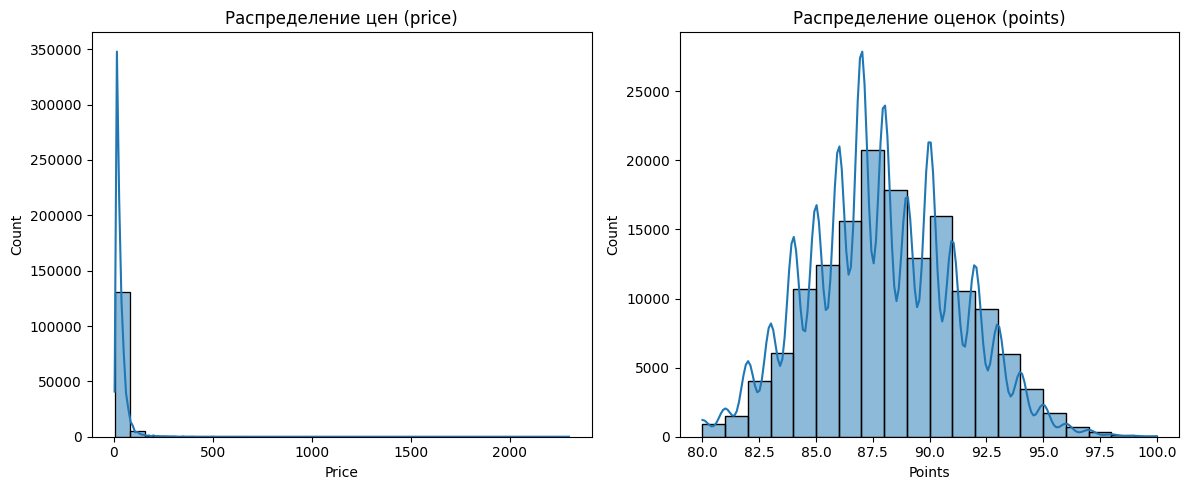

In [2]:
#Тут Распределение цен и оценок
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['price'].dropna(), bins=30, kde=True)
plt.title('Распределение цен (price)')
plt.xlabel('Price')
plt.subplot(1,2,2)
sns.histplot(df['points'], bins=20, kde=True)
plt.title('Распределение оценок (points)')
plt.xlabel('Points')
plt.tight_layout()
plt.show()

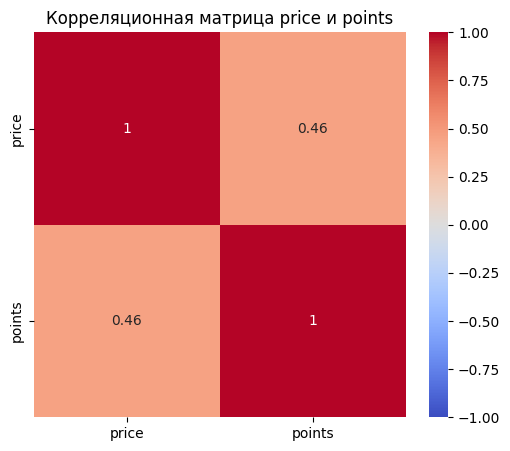

In [3]:
# А здесь Корреляционный анализ числовых признаков
numeric_cols = ['price', 'points']
corr = df[numeric_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Корреляционная матрица price и points')
plt.show()

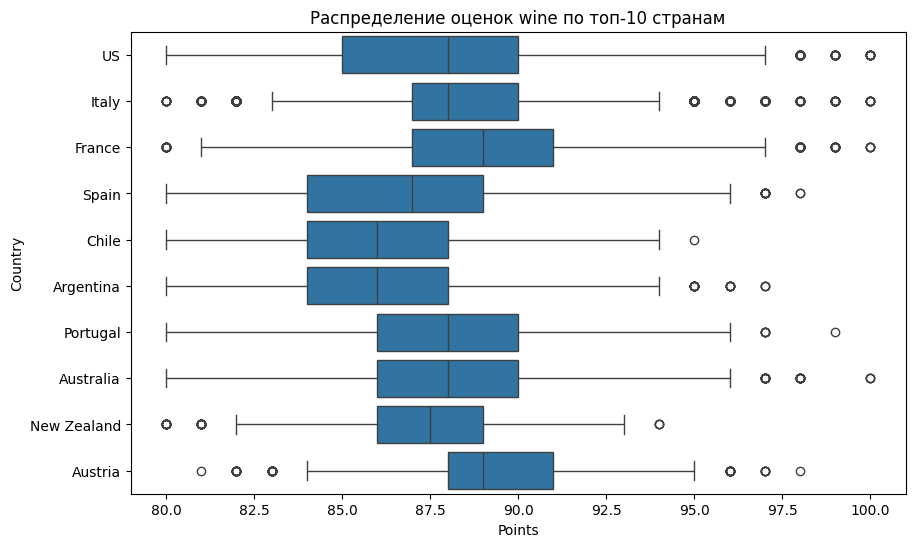

In [4]:
# Тут Boxplot оценок по топ-10 странам
top_countries = df['country'].value_counts().head(10).index
plt.figure(figsize=(10,6))
sns.boxplot(x='points', y='country', data=df[df['country'].isin(top_countries)], order=top_countries)
plt.title('Распределение оценок wine по топ-10 странам')
plt.xlabel('Points')
plt.ylabel('Country')
plt.show()

In [5]:
# Тута Средняя цена и оценка по стране (топ-10)
agg = df[df['country'].isin(top_countries)].groupby('country').agg({'price':'mean','points':'mean'}).reset_index()
agg.sort_values('points', ascending=False)

,country,price,points
2,Austria,31.192106,89.276742
4,France,45.619885,88.925870
5,Italy,37.547913,88.413664
7,Portugal,26.332615,88.057685
1,Australia,31.258480,87.892475
9,US,33.653808,87.818789
6,New Zealand,24.173290,87.554217
8,Spain,27.048529,86.646589
3,Chile,19.344780,86.296768
0,Argentina,20.794881,85.996093


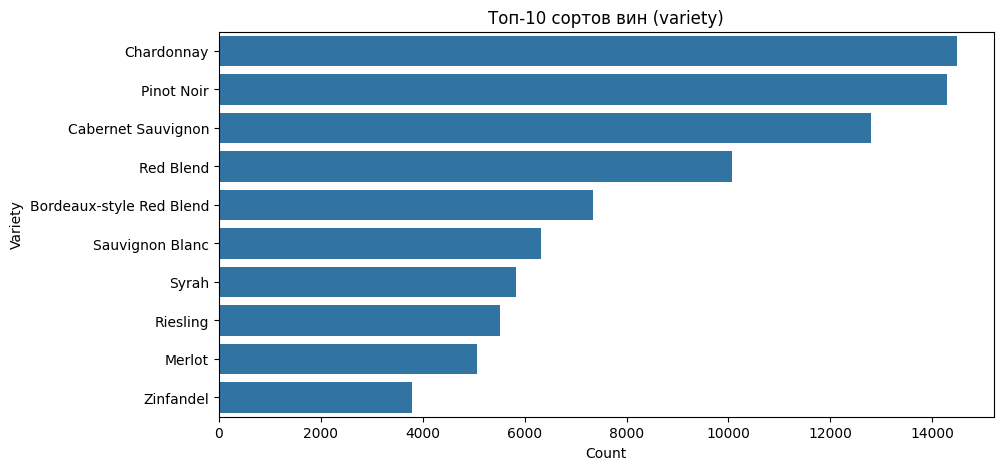

In [6]:
# Тута Топ-10 сортов вин
if 'variety' in df.columns:
    top_varieties = df['variety'].value_counts().head(10)
    plt.figure(figsize=(10,5))
    sns.barplot(y=top_varieties.index, x=top_varieties.values)
    plt.title('Топ-10 сортов вин (variety)')
    plt.xlabel('Count')
    plt.ylabel('Variety')
    plt.show()

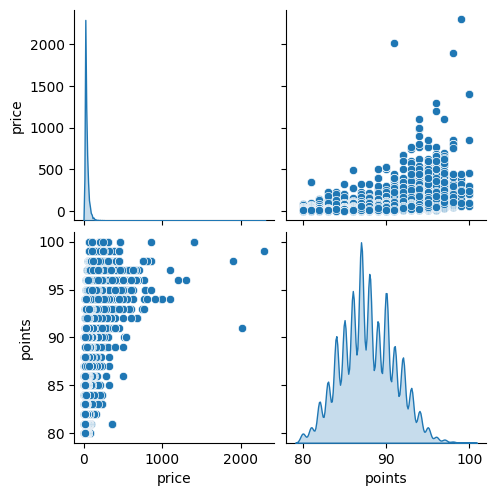

In [7]:
#А здеся Парный график для price и points
sns.pairplot(df[['price','points']].dropna(), diag_kind='kde')
plt.show()

In [8]:
# Тут Анализ регионов - топ-10 и средняя оценка
top_regions = df['region_1'].value_counts().head(10).index
region_stats = df[df['region_1'].isin(top_regions)].groupby('region_1')['points'].agg(['count','mean']).sort_values('mean', ascending=False)
region_stats

,count,mean
region_1,,
Toscana,1885,89.615385
Russian River Valley,3571,88.865304
Columbia Valley (WA),4975,88.636181
Napa Valley,6209,88.550813
Willamette Valley,2096,88.480439
Rioja,1893,87.238246
Sonoma County,1853,86.770642
Paso Robles,3053,86.167049
Mendoza,3586,85.893753


## 3. Обработка пропусков

In [9]:
#апроцент пропусков
df.isna().mean().sort_values(ascending=False)

df = df.dropna(subset=['points','price'])

#заполним пропуски
cat_cols = ['designation','region_1','region_2']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 137235 entries, 0 to 150929
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Unnamed: 0   137235 non-null  int64  
 1   country      137230 non-null  object 
 2   description  137235 non-null  object 
 3   designation  137235 non-null  object 
 4   points       137235 non-null  int64  
 5   price        137235 non-null  float64
 6   province     137230 non-null  object 
 7   region_1     137235 non-null  object 
 8   region_2     137235 non-null  object 
 9   variety      137235 non-null  object 
 10  winery       137235 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 12.6+ MB


## 4. Кодирование и масштабирование признаков

In [11]:
#  тут выбор признаков
features = ['country','province','region_1','winery','price']
target = 'points'

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, ['price']),
    ('cat', categorical_transformer, ['country','province','region_1','winery'])
])

## 5. Корреляционный анализ

In [12]:
#здесь  корреляция price и points
corr = df[['price','points']].corr()
corr

,price,points
price,1.000000,0.459863
points,0.459863,1.000000


## 6. Выбор метрик оценки качества
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² (коэффициент детерминации)

## 7. Выбор моделей
Используем 5 моделей:
1. LinearRegression
2. Ridge
3. DecisionTreeRegressor
4. RandomForestRegressor
5. GradientBoostingRegressor

## 8. Формирование обучающей и тестовой выборок

In [17]:
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 9. Baseline-модели

In [19]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}
results = []
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    results.append({
        'model': name,
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R2': r2_score(y_test, preds)
    })
results_df = pd.DataFrame(results)
results_df

,model,MAE,RMSE,R2
0,LinearRegression,1.733748,2.268167,0.503459
1,Ridge,1.734817,2.231819,0.519246
2,DecisionTree,1.315223,2.051364,0.593846
3,RandomForest,1.381863,1.935161,0.638557
4,GradientBoosting,1.923476,2.430365,0.429904


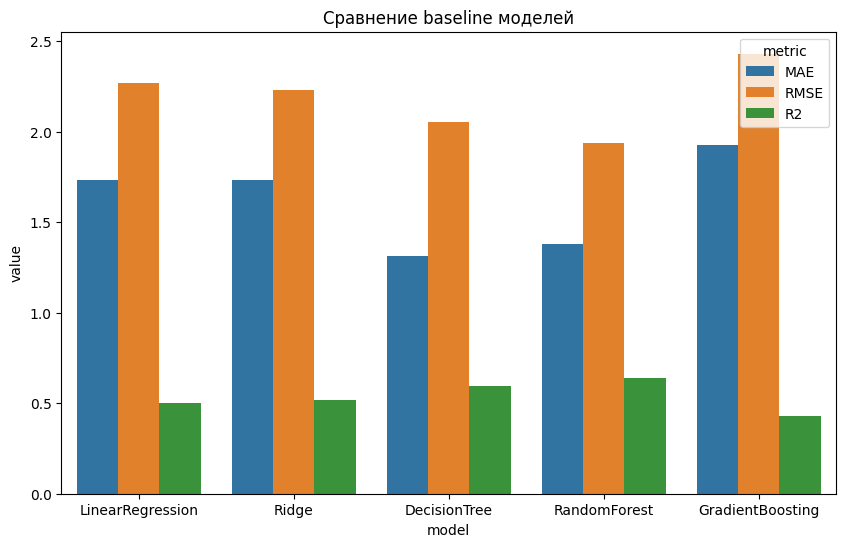

In [20]:
# тут Визуализация результатов baseline моделей
results_melt = results_df.melt(id_vars='model', var_name='metric', value_name='value')
plt.figure(figsize=(10,6))
sns.barplot(x='model', y='value', hue='metric', data=results_melt)
plt.title('Сравнение baseline моделей')
plt.show()

## 10. Настройка гиперпараметров (пример для RandomForest)

In [21]:
param_grid = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [None, 10]
}
pipe_rf = Pipeline(steps=[('preprocessor', preprocessor), ('model', RandomForestRegressor(random_state=42))])
grid_rf = GridSearchCV(pipe_rf, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_rf.fit(X_train, y_train)
grid_rf.best_params_

{'model__max_depth': None, 'model__n_estimators': 100}

## 11. Повторное обучение и сравнение

In [23]:
# вот тут Повторное обучение и сравнение
best_rf = grid_rf.best_estimator_
rf_preds = best_rf.predict(X_test)
rf_metrics = {
    'model': 'RandomForest_tuned',
    'MAE': mean_absolute_error(y_test, rf_preds),
    'RMSE': np.sqrt(mean_squared_error(y_test, rf_preds)),
    'R2': r2_score(y_test, rf_preds)
}
results_df = pd.concat([results_df, pd.DataFrame([rf_metrics])], ignore_index=True)
results_df

,model,MAE,RMSE,R2
0,LinearRegression,1.733748,2.268167,0.503459
1,Ridge,1.734817,2.231819,0.519246
2,DecisionTree,1.315223,2.051364,0.593846
3,RandomForest,1.381863,1.935161,0.638557
4,GradientBoosting,1.923476,2.430365,0.429904
5,RandomForest_tuned,1.381863,1.935161,0.638557


## 12. Выводы

По результатам видно, что тюнинг RandomForest улучшил RMSE и R² по сравнению с baseline.

Рекомендуется дальнейшее исследование: подбор гиперпараметров других моделей, анализ важности признаков, эксперимент с NLP-признаками из описаний.